In [1]:
# imports
import os
import gc

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tqdm import tqdm
from HamDiv import diversity as hamdiv

import utils

fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=3, fpSize=2048, includeChirality=True
)


In [2]:
## Helper functions
def load_enumeration_results_from_directory(directory):
    '''
        Load multiple enumeration results from a directory. This will read all 
        csv files existing in the directory.

        Args:
            directory (str): The directory containing the enumeration result files.

        Returns:
            pd.DataFrame: A DataFrame containing the combined enumeration results.

        Raises:
            FileNotFoundError: If the directory does not exist.
            ValueError: If no enumeration result files are found in the directory.
    '''
    if not os.path.exists(directory):
        raise FileNotFoundError(f"The directory '{directory}' does not exist.")
    
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    if not csv_files:
        raise ValueError(f"No enumeration result files found in the directory '{directory}'.")
    
    dataframes = []
    for file in csv_files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

def others_to_healer_result_format(df: pd.DataFrame, incoming_frmt: str='chemprojector'):
    '''
        Convert the result format of other enumerators to the one used by Healer.

        Args:
            df (pd.DataFrame): DataFrame containing the enumerated compounds.
            incoming_frmt (str): Format of the incoming DataFrame. Default is 'chemprojector'.

        Returns:
            pd.DataFrame: DataFrame in Healer's result format. The output will include the additional columns:
                - 'Product': SMILES of the enumerated compound.
                - 'num_steps': Number of steps taken to enumerate the compound.
                - 'Similarity_to_query': Similarity of the enumerated compound to the query compound.
                - 'ID': Unique identifier for the enumerated compound as in healer.
    '''
    if incoming_frmt == 'chemprojector':
        targets = df['target'].unique()
        # output_df = pd.DataFrame(columns=['smiles', 'num_steps', 'Similarity_to_query'])
        output_dfs = []
        for target in targets:
            target_df = df[df['target'] == target]
            tmp = pd.DataFrame({'target': [target], 'smiles': [target]})
            target_df = pd.concat([tmp, target_df], axis=0)
            fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in target_df['smiles'].values]
            tani_sims = Chem.DataStructs.BulkTanimotoSimilarity(fps[0], fps)
            target_df['Similarity_to_query'] = np.round(tani_sims, 2)
            target_df = target_df[['smiles', 'num_steps', 'Similarity_to_query']].sort_values(
                by='Similarity_to_query', ascending=False
            ).reset_index(drop=True)
            target_df['ID'] = [f'HEAL_{i:06d}' for i in range(len(target_df))]
            target_df = target_df.rename(columns={'smiles': 'Product'})
            output_dfs.append(target_df)
            # output_df = pd.concat([output_df, target_df], axis=0)
    
    return pd.concat(output_dfs, axis=0)

def get_top_n_dfs(data, n=[0, 1, 10, 25]) -> list[pd.DataFrame]:
    '''
        Get the best scoring n enumerations for each query. If n=0,
        return the query molecules.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (list): A list of integers representing the number of top enumerations to retrieve.
                Default is [0, 1, 10, 25]. If n=0, the query molecules are returned.

        Returns:
            list: A list of DataFrames, each containing the top n enumerations for each query.
    '''
    top_n_dfs = []
    for n_val in n:
        if n_val == 0:   
            top_n_df = data[data['ID'] == 'HEAL_000000'].copy()
        else:
            top_n_df = data[data['ID'].isin([f'HEAL_{i:06d}' for i in range(1, n_val + 1)])].copy()
        top_n_df['SA_score'] = [utils.get_sascore(x) for x in top_n_df['Product'].values]
        top_n_dfs.append(top_n_df)

    return top_n_dfs

def calculate_statistics(dfs, top_n_partitions):
    '''
        Calculate the success rate, reconstruction rate, and top_n_average similarity.

        Args:
            dfs (list): A list of DataFrames containing the top-n datasets. 
            top_n_partitions (list): A list of integers representing the number of 
                top enumerations to consider. should be same order as dfs.

        Returns:
            dict: A dictionary containing the calculated statistics.
                - 'Success Rate': The ratio of successful enumerations to total enumerations.
                - 'Reconstruction Rate': The ratio of successfully reconstructed enumerations to total enumerations.
                - 'Top n Average Similarity': The average similarity of the top n enumerations.
                - 'Number of Rxn Steps (Top n)': The average number of reaction steps for the top n enumerations.
                - 'Average Diversity': The average diversity of the top n enumerations.
            dict: A dictionary containing the diversity calculations for each enumeration.
                - 'Top n Diversity': The diversity scores for the top n enumerations.
    '''
    if len(dfs) != len(top_n_partitions):
        raise ValueError("The length of dfs and top_n_partitions must be the same.")
    top0_idx = top_n_partitions.index(0)
    top1_idx = top_n_partitions.index(1)
    reconstructed = dfs[top1_idx][dfs[top1_idx]['Similarity_to_query'] == 1.0]
    statistics = {
        'Success Rate': len(dfs[top1_idx]) / len(dfs[top0_idx]),
        'Reconstruction Rate': len(reconstructed) / len(dfs[top0_idx]),
    }
    diversity_outputs = {}
    for i, n in enumerate(top_n_partitions):
        if n == 0:
            continue
        statistics[f'Top {n} Average Similarity'] = dfs[i]['Similarity_to_query'].mean()
        statistics[f'Number of Rxn Steps (Top {n})'] = dfs[i]['num_steps'].mean()
        if n != 1:
            enum_starts = [idx for idx, x in enumerate(dfs[i]['ID']) if x == 'HEAL_000001']
            smiles = dfs[i]['Product'].values
            divs = []
            for k in range(len(enum_starts) - 1):
                if enum_starts[-1] == enum_starts[k + 1]:
                    enums_k = smiles[enum_starts[k]:]
                else:
                    enums_k = smiles[enum_starts[k]:enum_starts[k + 1]]
                if len(enums_k) > 1:
                    divs.append(get_diversity_score(enums_k, mode='HamDiv'))
                else:
                    divs.append(0)
            divs = np.array(divs)
            statistics[f'Top {n} Average Diversity'] = divs.mean()
            diversity_outputs[f'Top {n} Diversity'] = divs

    return statistics, diversity_outputs

def get_diversity_score(smiles, mode='HamDiv'):
    '''
        Calculate the diversity score of a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.
            mode (str): The method to calculate diversity. Options are
                HamDiv, FG, RS, BM, Richness, IntDiv, SumDiv, Diam, SumDiam,
                Bot, SumBot, DPP, and NCircles-0.x.

        Returns:
            float: The diversity score.
    '''
    if mode in ['FG', 'RS', 'BM', 'Richness']:
        return hamdiv.diversity_all(smiles, mode=mode)
    
    dists = get_pdist_matrix(smiles)
    if mode == 'HamDiv':
        n = len(smiles)
        comp_method = 'exact_dp' if n <= 20 else 'local_search' if n <= 1000 else 'greedy_tsp'
        return hamdiv.HamDiv(smiles, dists=dists, method=comp_method)
    
    return hamdiv.diversity_all(smiles, dists=dists, mode=mode)

def get_pdist_matrix(smiles):
    '''
        Calculate the pairwise distance matrix for a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.

        Returns:
            np.ndarray: The pairwise distance matrix.
    '''
    fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in smiles]
    sims = np.zeros((len(smiles), len(smiles)))
    for i in range(len(smiles)):
        sims[i] = Chem.DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    return 1 - sims

def min_max_normalize(arr):
    '''
        Min-max normalization of an array.

        Args:
            arr (np.ndarray): The array to be normalized.

        Returns:
            np.ndarray: The normalized array.
    '''
    arr = np.array(arr)
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    return (arr - arr_min) / (arr_max - arr_min)


# Enumerations Results


In [ ]:
## load enumerations of benchmark datasets
sim_cutoff = 0.25
top_n_partitions = [0, 1, 5]

## HEALER results
# Enamine REAL 1k random
enums = pd.read_csv('healer_results/healer_enamine_1k_random_enums.csv')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
enums['num_steps'] = [1] * len(enums)
healer_enamine_dfs = get_top_n_dfs(enums, n=top_n_partitions)
healer_enamine_stats, healer_enamine_diversity = calculate_statistics(healer_enamine_dfs, top_n_partitions)

# ChEMBL Ro5 1k random
enums = pd.read_csv('healer_results/healer_chembl_1k_random_enums.csv')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
enums['num_steps'] = [1] * len(enums)
healer_chembl_dfs = get_top_n_dfs(enums, n=top_n_partitions)
healer_chembl_stats, healer_chembl_diversity = calculate_statistics(healer_chembl_dfs, top_n_partitions)

# ASKCOS Unsynthesizable 1k random
enums = pd.read_csv('healer_results/healer_askcos_unsynthesizable_1k_random_enums.csv')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
enums['num_steps'] = [1] * len(enums)
healer_askcos_dfs = get_top_n_dfs(enums, n=top_n_partitions)
healer_askcos_stats, healer_askcos_diversity = calculate_statistics(healer_askcos_dfs, top_n_partitions)

## ChemProjector results
# Enamine REAL 1k random
enums = pd.read_csv(
    'chemprojector_results/chemprojector_enamine_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
chemprojector_enamine_dfs = get_top_n_dfs(enums, n=top_n_partitions)
chemprojector_enamine_stats, chemprojector_enamine_diversity = calculate_statistics(chemprojector_enamine_dfs, top_n_partitions)

# ChEMBL Ro5 1k random
enums = pd.read_csv(
    'chemprojector_results/chemprojector_chembl_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
chemprojector_chembl_dfs = get_top_n_dfs(enums, n=top_n_partitions)
chemprojector_chembl_stats, chemprojector_chembl_diversity = calculate_statistics(chemprojector_chembl_dfs, top_n_partitions)

# ASKCOS Unsynthesizable 1k random
enums = pd.read_csv(
    'chemprojector_results/chemprojector_askcos_unsynthesizable_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
chemprojector_askcos_dfs = get_top_n_dfs(enums, n=top_n_partitions)
chemprojector_askcos_stats, chemprojector_askcos_diversity = calculate_statistics(chemprojector_askcos_dfs, top_n_partitions)

## Synformer results
# Enamine REAL 1k random
enums = pd.read_csv(
    'synformer_results/synformer_enamine_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
synformer_enamine_dfs = get_top_n_dfs(enums, n=top_n_partitions)
synformer_enamine_stats, synformer_enamine_diversity = calculate_statistics(synformer_enamine_dfs, top_n_partitions)

# ChEMBL Ro5 1k random
enums = pd.read_csv(
    'synformer_results/synformer_chembl_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
synformer_chembl_dfs = get_top_n_dfs(enums, n=top_n_partitions)
synformer_chembl_stats, synformer_chembl_diversity = calculate_statistics(synformer_chembl_dfs, top_n_partitions)

# ASKCOS Unsynthesizable 1k random
enums = pd.read_csv(
    'synformer_results/synformer_askcos_unsynthesizable_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
synformer_askcos_dfs = get_top_n_dfs(enums, n=top_n_partitions)
synformer_askcos_stats, synformer_askcos_diversity = calculate_statistics(synformer_askcos_dfs, top_n_partitions)

del enums
gc.collect()

# Comparison of Enumeration Statistics by Dataset and by Method


In [ ]:
# multi-label table from dictionaries
def highlight_extremes(row, min_rows):
    styles = pd.Series("", index=row.index)
    prefer_min = row.name in min_rows

    # iterate over each Dataset group
    for ds in row.index.get_level_values(0).unique():
        sub = row[ds]  # Series indexed by Method
        target_value = sub.min() if prefer_min else sub.max()
        # bold all cells equal to the target
        mask = sub == target_value
        for method in sub.index:
            if mask.loc[method]:
                styles[(ds, method)] = "font-weight: bold"

    return styles

table_styles = [
    {# index names
        'selector': 'th.index_name:(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: right;'
    },
    {# row index name
        'selector': 'th.index_name:not(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: left;'
    }
    {# first level column headers
        'selector': 'th.col_heading.level0',
        'props': 'text-align: center; font-size: 16px; color: black'
    },
    {# second level column headers
        'selector': 'th.col_heading.level1',
        'props': 'font-size: 16px; font-weight: bold; text-align: center; color: black;'
    },
    {# header background
        'selector': 'thead th',
        'props': 'background-color: #0d97ff;' 
    },
    {# row headers
        'selector': 'th.row_heading',
        'props': 'text-align: left; font-size: 16px; font-weight: bold;'
    },
    {# even rows
        'selector': 'tbody tr:nth-child(even)',
        'props': 'background-color: #60bafd; color: black;'
    },
    {# odd rows
        'selector': 'tbody tr:nth-child(odd)',
        'props': 'background-color: #93d1ff; color: black;'
    },
]
multi_index = pd.MultiIndex.from_product(
    [['Enamine', 'ChEMBL', 'ASKCOS'], ['HEALER', 'ChemProjector', 'Synformer']],
    names=['Dataset', 'Method']
)
stats_df = pd.DataFrame(
    [healer_enamine_stats, chemprojector_enamine_stats, synformer_enamine_stats,
     healer_chembl_stats, chemprojector_chembl_stats, synformer_chembl_stats,
     healer_askcos_stats, chemprojector_askcos_stats, synformer_askcos_stats],
    index=multi_index,
).T
stats_df.index.name = 'Statistic'
s = stats_df.style\
    .format(precision=2)\
    .set_caption('Comparison of Methods on Different Datasets')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in stats_df.index if 'Rxn Steps' in metric])
s


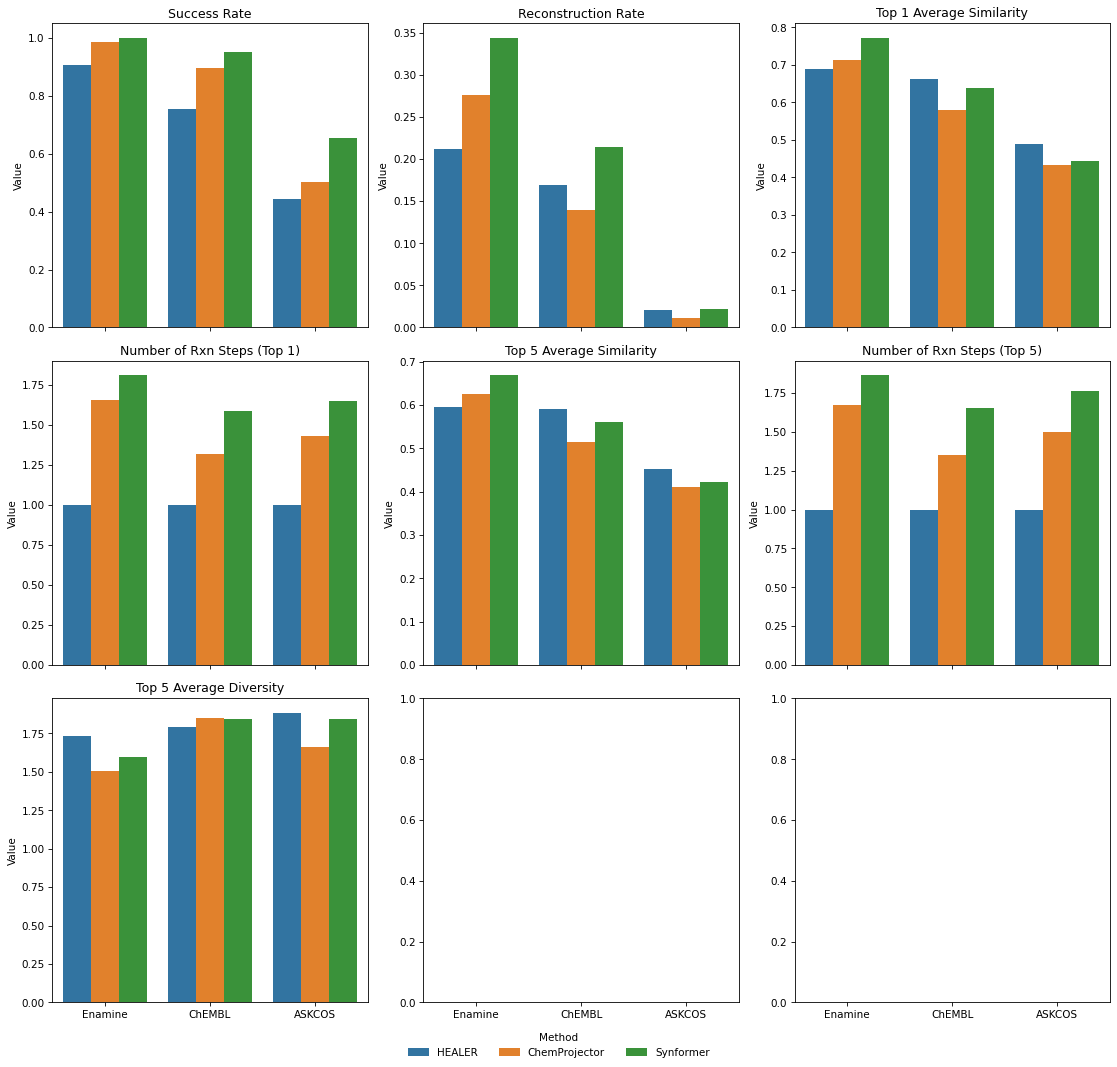

In [11]:
def plot_metric(ax, df_metric):
    # Draw grouped bars with seaborn
    sns.barplot(
        data=df_metric,
        x='Dataset',
        y='Value',
        hue='Method',
        ax=ax,
    )
    
    # Title & labels
    ax.set_title(df_metric['Statistic'].iloc[0])
    ax.set_ylabel("Value")
    ax.set_xlabel("")  # keep x-label clean
    
# melt the DataFrame for plotting
melt_df = stats_df.stack(level=['Dataset', 'Method'], future_stack=True).reset_index(name='Value')

stats = melt_df['Statistic'].unique()
n_stats = len(stats)

fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, dpi=75)
axes = axes.flatten()

for ax, stat in zip(axes, stats):
    subset = melt_df[melt_df['Statistic'] == stat]
    plot_metric(ax, subset)
    ax.legend_.remove()

# single legend at bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title="Method",
           loc='lower center',
           ncol=len(labels),
           frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# SA Score Distributions by Method and by Dataset

ValueError: y-axis is already shared

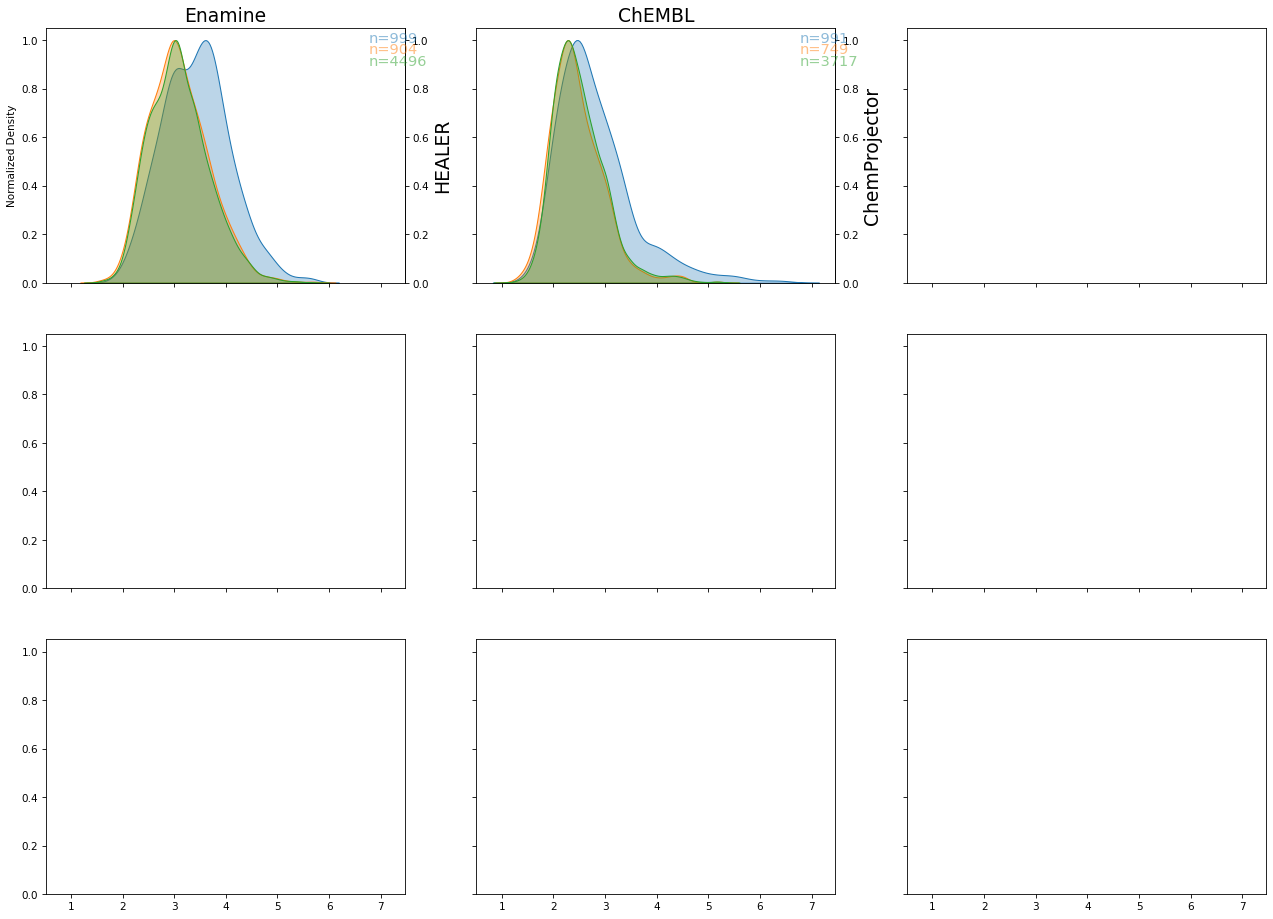

In [ ]:
## plot SA score distributions
# helper plot functions
def kdeplot(data, line_number, **kwargs):
    ax = sns.kdeplot(data, **kwargs)
    if 'fill' in kwargs.keys() and kwargs['fill']==True:
        path = ax.collections[line_number].get_paths()
        ys = min_max_normalize(path[0].vertices[:, 1])
        path[0].vertices[:, 1] = ys
    else:
        line = ax.lines[line_number]
        line.set_ydata(min_max_normalize(line.get_ydata()))
    ax.set_ylim(0, 1.05)       
    ax.autoscale_view()
    return ax

def plot_sascore_distributions(dfs, labels, ax, normalize_y=True, title=None, sec_ylabel=None):
    if normalize_y:
        for i, (df, label) in enumerate(zip(dfs, labels)):
            kdeplot(df['SA_score'], i, color=f'C{i}', label=label, alpha=0.3, fill=True, ax=ax)
    else:
        for i, (df, label) in enumerate(zip(dfs, labels)):
            sns.kdeplot(df['SA_score'], color=f'C{i}', label=label, alpha=0.3, fill=True, ax=ax)
    # annotate number of samples for each distribution
    for i, (df, label) in enumerate(zip(dfs, labels)):
        ax.annotate(f'n={len(df)}', xy=(0.90, 0.96-(i*0.045)), xycoords='axes fraction', fontsize=14,
                     ha='left', va='center', color=f'C{i}', alpha=0.5)
    ax.set_title(f'{title}', fontsize=18)
    ax.set_xlabel('SA Score')
    ax.set_ylabel('Normalized Density')
    if sec_ylabel:
        secax = ax.secondary_yaxis('right')
        secax.set_ylabel(sec_ylabel, fontsize=18, rotation=90)
    ax.legend()

# plotting
res_dfs = [
    healer_enamine_dfs, healer_chembl_dfs, healer_askcos_dfs,
    chemprojector_enamine_dfs, chemprojector_chembl_dfs, chemprojector_askcos_dfs,
    synformer_enamine_dfs, synformer_chembl_dfs, synformer_askcos_dfs
]
# titles = [
#     'HEALER Enamine', 'HEALER ChEMBL', 'HEALER ASKCOS',
#     'ChemProjector Enamine', 'ChemProjector ChEMBL', 'ChemProjector ASKCOS',
#     'Synformer Enamine', 'Synformer ChEMBL', 'Synformer ASKCOS'
# ]
titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * 6
row_titles = ['HEALER', 'ChemProjector', 'Synformer'] + [''] * 6
fig, axes = plt.subplots(3, 3, figsize=(21, 15), dpi=75, sharex=True, sharey=True,)
for i, (df, title, r_title) in enumerate(zip(res_dfs, titles, row_titles)):
    ax = axes[i//3, i%3]
    plot_sascore_distributions(df, ['Queries', 'Top-1', 'Top-10', 'Top-25'], ax, 
                               normalize_y=True, title=title, sec_ylabel=r_title)
    ax.legend_.remove()
fig.suptitle('SA Score Distributions of Enumerated Compounds', fontsize=24)
fig.tight_layout()
fig.show()
